# Sentiment Analysis Optimization using Bio Inspired Algorithm
## Dataset provided : https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences
3 TSV Files 
### Members 
- Aniruddha Panchal
- kinjal Surve
- Tanuj Balivada
- Vanshika Chinchkhede

Models experimented :
- KNN (F1 )
- KNN (SPECIFICITY)

- RANDOM FOREST (F1)
- RANDOM FOREST (SPECIFICITY)

- DECISION TREE (F1)
- DECISION TREE (SPECIFICITY)

- SUM (F1)
- SUM (SPECIFICITY)

- GRADIENT B (F1)
- GRADIENT B (SPECIFICITY)

- XGRADIENT B (F1)
- XGRADIENT B (SPECIFICITY)

Algorithms : 
- Particle Swarm Optimization (PSO) – inspired by bird flocking/fish schooling.

- Genetic Algorithm (GA) – based on natural selection and evolution.

- Ant Colony Optimization (ACO) – mimics how ants find shortest paths.

- Bat Algorithm – inspired by echolocation of bats.

- Cuckoo Search – mimics cuckoo birds laying eggs in other nests.

- Firefly Algorithm – based on fireflies attracting each other with light.

- Artificial Bee Colony (ABC) – inspired by honeybee foraging behavior.

## Dataset analysis 

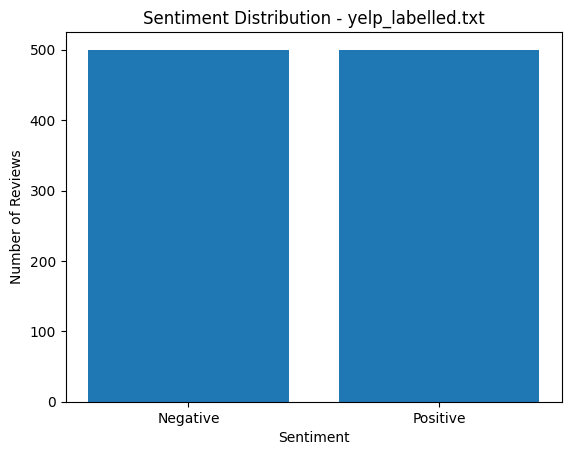

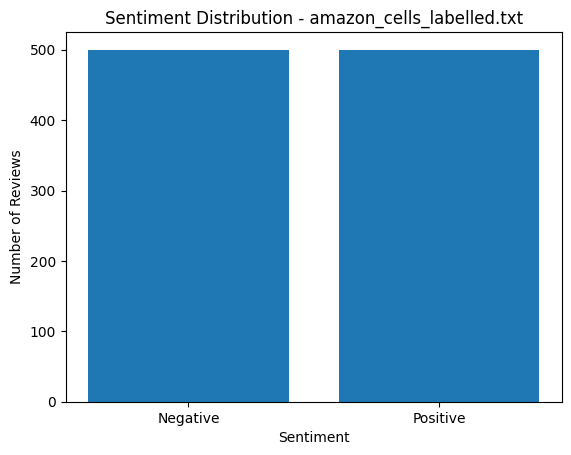

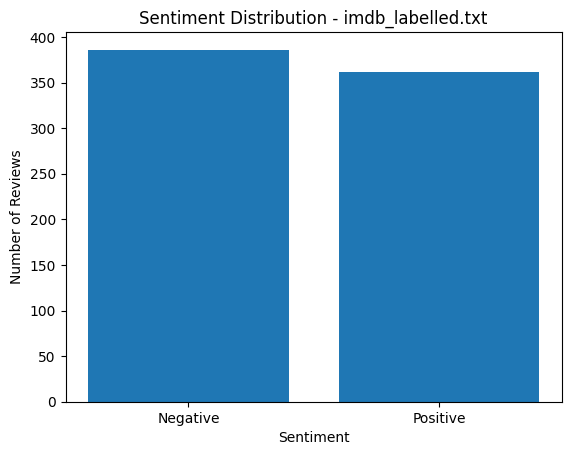

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# List of files
files = ['yelp_labelled.txt', "amazon_cells_labelled.txt", 'imdb_labelled.txt']

# Loop through files
for file in files:
    df = pd.read_csv(file, sep='\t', header=None, names=['text', 'label'])
    counts = df['label'].value_counts()
    
    plt.bar(['Negative', 'Positive'], counts)
    plt.title(f'Sentiment Distribution - {file}')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()


 The data in the first two datasets is roughly balanced between positive and negative classes, whereas the third dataset (IMDb ratings) has a slightly higher number of negative samples; however, this minor imbalance can be safely ignored.

# KNN

## KNN (PSO)

In [35]:
import pandas as pd

files = ["yelp_labelled.txt", "imdb_labelled.txt", "amazon_cells_labelled.txt"]

dfs = [pd.read_csv(f, sep='\t', header=None, names=['statement', 'value']) for f in files]

data = pd.concat(dfs, ignore_index=True)

X = data['statement']
y = data['value']


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer(max_features=500)  # limit vocab for PSO
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)


In [37]:
from pyswarm import pso
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
import numpy as np

def objective(features_mask):
    features_mask = np.array(features_mask) > 0.5
    if np.sum(features_mask) == 0:
        return 1.0  # penalty for empty feature set
    X_train_sel = X_train_vect[:, features_mask]
    X_test_sel = X_test_vect[:, features_mask]
    
    model = MultinomialNB()
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    return 1 - f1  # PSO minimizes


In [38]:
num_features = X_train_vect.shape[1]
lb = [0] * num_features
ub = [1] * num_features

best_features, best_cost = pso(objective, lb, ub, swarmsize=10, maxiter=5)

print("Best F1 Score:", 1 - best_cost)

knn_pso_f1 = 1 - best_cost

Stopping search: maximum iterations reached --> 5
Best F1 Score: 0.7504690431519699


In [39]:
from sklearn.metrics import confusion_matrix, f1_score

best_mask = np.array(best_features) > 0.5

X_train_sel = X_train_vect[:, best_mask]
X_test_sel = X_test_vect[:, best_mask]

model = MultinomialNB()
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Specificity:", specificity)
knn_pso_specificity = specificity


Specificity: 0.7281879194630873


## KNN (GA)

In [40]:
import random
import numpy as np
from deap import base, creator, tools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]

creator.create("FitnessMax", base.Fitness, weights=(1.0,))  
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)  
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=num_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


c:\Users\ANIRUDDUHA\anaconda3\envs\tech\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\ANIRUDDUHA\anaconda3\envs\tech\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [41]:
def fitness(individual):
    mask = np.array(individual) > 0
    if np.sum(mask) == 0: 
        return 0,
    
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    score = (f1 + specificity) / 2
    return score,
    
toolbox.register("evaluate", fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)


In [42]:
population = toolbox.population(n=20)
NGEN = 10 

for gen in range(NGEN):
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))
    
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.5:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
    
    for mutant in offspring:
        if random.random() < 0.2:
            toolbox.mutate(mutant)
            del mutant.fitness.values
    
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
    
    population[:] = offspring

best_ind = tools.selBest(population, 1)[0]
print("Best F1+Specificity Score:", fitness(best_ind)[0])
selected_features = np.where(np.array(best_ind) > 0)[0]


Best F1+Specificity Score: 0.6584045149481391


In [43]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_ga_f1 = f1
knn_ga_specificity = specificity


Final F1 Score: 0.6590909090909091
Final Specificity: 0.6577181208053692


## KNN (ANT)

In [44]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]

# ACO parameters
num_ants = 20
num_iterations = 10
pheromone = np.ones(num_features)
alpha = 1  # influence of pheromone
beta = 2   # influence of heuristic (we'll use uniform)
evaporation = 0.1

best_score = 0
best_features = None

for iteration in range(num_iterations):
    all_solutions = []
    all_scores = []

    for ant in range(num_ants):
        # Construct solution probabilistically
        prob = (pheromone ** alpha) * (np.ones(num_features) ** beta)
        prob = prob / np.sum(prob)
        selected = np.random.rand(num_features) < prob  # binary mask
        
        if np.sum(selected) == 0:
            selected[random.randint(0, num_features-1)] = True  # ensure at least 1 feature
        
        X_train_sel = X_train_vect[:, selected]
        X_test_sel = X_test_vect[:, selected]
        
        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        
        f1 = f1_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        score = (f1 + specificity) / 2  # combined metric

        all_solutions.append(selected)
        all_scores.append(score)

        # Update best
        if score > best_score:
            best_score = score
            best_features = selected

    # Evaporate pheromones
    pheromone = (1 - evaporation) * pheromone

    # Deposit pheromone proportional to score
    for sol, score in zip(all_solutions, all_scores):
        pheromone += sol * score

    print(f"Iteration {iteration+1}, Best Score so far: {best_score:.4f}")

# Selected feature indices
selected_indices = np.where(best_features)[0]
print("Selected Feature Indices:", selected_indices)


Iteration 1, Best Score so far: 0.3287
Iteration 2, Best Score so far: 0.3507
Iteration 3, Best Score so far: 0.3520
Iteration 4, Best Score so far: 0.3666
Iteration 5, Best Score so far: 0.3816
Iteration 6, Best Score so far: 0.5320
Iteration 7, Best Score so far: 0.5320
Iteration 8, Best Score so far: 0.5320
Iteration 9, Best Score so far: 0.5601
Iteration 10, Best Score so far: 0.5601
Selected Feature Indices: [213]


In [45]:
X_train_sel = X_train_vect[:, selected_indices]
X_test_sel = X_test_vect[:, selected_indices]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_ant_f1 = f1
knn_ant_specificity = specificity

Final F1 Score: 0.22082018927444794
Final Specificity: 0.8993288590604027


## KNN (BAT)

In [46]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]

n_bats = 20
n_iterations = 10
A = 0.5 
r = 0.5 
f_min, f_max = 0, 1
alpha, gamma = 0.9, 0.9 

positions = np.random.rand(n_bats, num_features) > 0.5  # binary mask
velocities = np.zeros((n_bats, num_features))
best_score = 0
best_position = None


In [47]:
def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2


In [48]:
for t in range(n_iterations):
    for i in range(n_bats):
        f = f_min + (f_max - f_min) * random.random()
        velocities[i] += (positions[i] ^ (best_position if best_position is not None else positions[i])) * f
        new_pos = positions[i] ^ (velocities[i] > 0.5)  # XOR for binary update

        if random.random() > r: 
            new_pos = positions[i] ^ (np.random.rand(num_features) > 0.5)

        score = fitness(new_pos)
        if score > fitness(positions[i]) and random.random() < A:
            positions[i] = new_pos
            A *= alpha
            r = r * (1 - np.exp(-gamma * t))

        if score > best_score:
            best_score = score
            best_position = new_pos

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_position)[0]


Iteration 1, Best Score so far: 0.6512
Iteration 2, Best Score so far: 0.6512
Iteration 3, Best Score so far: 0.6512
Iteration 4, Best Score so far: 0.6512
Iteration 5, Best Score so far: 0.6512
Iteration 6, Best Score so far: 0.6612
Iteration 7, Best Score so far: 0.6612
Iteration 8, Best Score so far: 0.6612
Iteration 9, Best Score so far: 0.6612
Iteration 10, Best Score so far: 0.6612


In [50]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_bat_f1 = f1
knn_bat_specificity = specificity


Final F1 Score: 0.6377952755905512
Final Specificity: 0.6845637583892618


## KNN (CUKOO)

In [22]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]
n_nests = 20
n_iterations = 10
pa = 0.25 
best_score = 0
best_nest = None

nests = np.random.rand(n_nests, num_features) > 0.5


In [23]:
def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2


In [28]:
import math
import numpy as np
import random

def levy_flight(Lambda=1.5):
    sigma = (math.gamma(1 + Lambda) * math.sin(math.pi * Lambda / 2) /
             (math.gamma((1 + Lambda) / 2) * Lambda * 2 ** ((Lambda - 1) / 2))) ** (1 / Lambda)
    u = np.random.randn(num_features) * sigma
    v = np.random.randn(num_features)
    step = u / np.abs(v) ** (1 / Lambda)
    return step

for t in range(n_iterations):
    for i in range(n_nests):
        step = levy_flight()
        new_nest = nests[i] ^ (np.random.rand(num_features) < np.abs(step))  # XOR update

        if np.sum(new_nest) == 0:
            new_nest[random.randint(0, num_features-1)] = True

        score = fitness(new_nest)

        if score > fitness(nests[i]):
            nests[i] = new_nest

        if score > best_score:
            best_score = score
            best_nest = new_nest

    for i in range(n_nests):
        if random.random() < pa:
            nests[i] = np.random.rand(num_features) > 0.5

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_nest)[0]


Iteration 1, Best Score so far: 0.6671
Iteration 2, Best Score so far: 0.7076
Iteration 3, Best Score so far: 0.7076
Iteration 4, Best Score so far: 0.7076
Iteration 5, Best Score so far: 0.7076
Iteration 6, Best Score so far: 0.7076
Iteration 7, Best Score so far: 0.7076
Iteration 8, Best Score so far: 0.7076
Iteration 9, Best Score so far: 0.7076
Iteration 10, Best Score so far: 0.7076


In [52]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_cukoo_f1 = f1
knn_cukoo_specificity = specificity

Final F1 Score: 0.6377952755905512
Final Specificity: 0.6845637583892618


## KNN (Firefly Algorithm)

In [30]:
import numpy as np
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]
n_fireflies = 20
n_iterations = 10
alpha = 0.5 
beta0 = 1.0 
gamma = 1.0  
best_score = 0
best_firefly = None

fireflies = np.random.rand(n_fireflies, num_features) > 0.5

def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2

for t in range(n_iterations):
    for i in range(n_fireflies):
        for j in range(n_fireflies):
            if fitness(fireflies[j]) > fitness(fireflies[i]):
                r = np.sum(fireflies[i] != fireflies[j])
                beta = beta0 * np.exp(-gamma * r ** 2)
                move = beta * (fireflies[j] ^ fireflies[i])
                new_pos = fireflies[i] ^ (move > 0.5)
                new_pos ^= (np.random.rand(num_features) < alpha)
                if np.sum(new_pos) == 0:
                    new_pos[random.randint(0, num_features-1)] = True
                fireflies[i] = new_pos
                score = fitness(new_pos)
                if score > best_score:
                    best_score = score
                    best_firefly = new_pos

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_firefly)[0]


Iteration 1, Best Score so far: 0.6398
Iteration 2, Best Score so far: 0.6563
Iteration 3, Best Score so far: 0.6563
Iteration 4, Best Score so far: 0.6563
Iteration 5, Best Score so far: 0.6640
Iteration 6, Best Score so far: 0.6640
Iteration 7, Best Score so far: 0.6711
Iteration 8, Best Score so far: 0.6789
Iteration 9, Best Score so far: 0.6798
Iteration 10, Best Score so far: 0.6826


In [53]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)


y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_firefly_f1 = f1
knn_firefly_specificity = specificity


Final F1 Score: 0.6377952755905512
Final Specificity: 0.6845637583892618


## KNN (ABC)

In [32]:
import numpy as np
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]
n_bees = 20
n_iterations = 10
limit = 5 
best_score = 0
best_solution = None

foods = np.random.rand(n_bees, num_features) > 0.5
trial = np.zeros(n_bees)  

def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2

for t in range(n_iterations):
    for i in range(n_bees):
        k = random.choice([x for x in range(n_bees) if x != i])
        phi = np.random.uniform(-1, 1, num_features)
        new_solution = foods[i] ^ ((foods[i] ^ foods[k]) & (phi > 0))
        if np.sum(new_solution) == 0:
            new_solution[random.randint(0, num_features-1)] = True
        new_score = fitness(new_solution)
        if new_score > fitness(foods[i]):
            foods[i] = new_solution
            trial[i] = 0
        else:
            trial[i] += 1
        if new_score > best_score:
            best_score = new_score
            best_solution = new_solution

    fitness_vals = np.array([fitness(f) for f in foods])
    probs = fitness_vals / (fitness_vals.sum() + 1e-9)
    for i in range(n_bees):
        if random.random() < probs[i]:
            k = random.choice([x for x in range(n_bees) if x != i])
            phi = np.random.uniform(-1, 1, num_features)
            new_solution = foods[i] ^ ((foods[i] ^ foods[k]) & (phi > 0))
            if np.sum(new_solution) == 0:
                new_solution[random.randint(0, num_features-1)] = True
            new_score = fitness(new_solution)
            if new_score > fitness(foods[i]):
                foods[i] = new_solution
                trial[i] = 0
            else:
                trial[i] += 1
            if new_score > best_score:
                best_score = new_score
                best_solution = new_solution

    for i in range(n_bees):
        if trial[i] > limit:
            foods[i] = np.random.rand(num_features) > 0.5
            trial[i] = 0

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_solution)[0]


Iteration 1, Best Score so far: 0.6409
Iteration 2, Best Score so far: 0.6409
Iteration 3, Best Score so far: 0.6872
Iteration 4, Best Score so far: 0.6872
Iteration 5, Best Score so far: 0.6872
Iteration 6, Best Score so far: 0.6872
Iteration 7, Best Score so far: 0.6872
Iteration 8, Best Score so far: 0.6945
Iteration 9, Best Score so far: 0.6945
Iteration 10, Best Score so far: 0.6945


In [55]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)

y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_abc_f1 = f1
knn_abc_specificity = specificity

Final F1 Score: 0.6377952755905512
Final Specificity: 0.6845637583892618


## visualization


In [56]:
algorithms = ["PSO", "GA", "Bat", "ACO", "Firefly", "ABC", "Cuckoo"]
f1_scores = [knn_pso_f1, knn_ga_f1, knn_bat_f1, knn_ant_f1, knn_firefly_f1, knn_abc_f1, knn_cukoo_f1]
specificity = [knn_pso_specificity, knn_ga_specificity, knn_bat_specificity, knn_ant_specificity,
               knn_firefly_specificity, knn_abc_specificity, knn_cukoo_specificity]


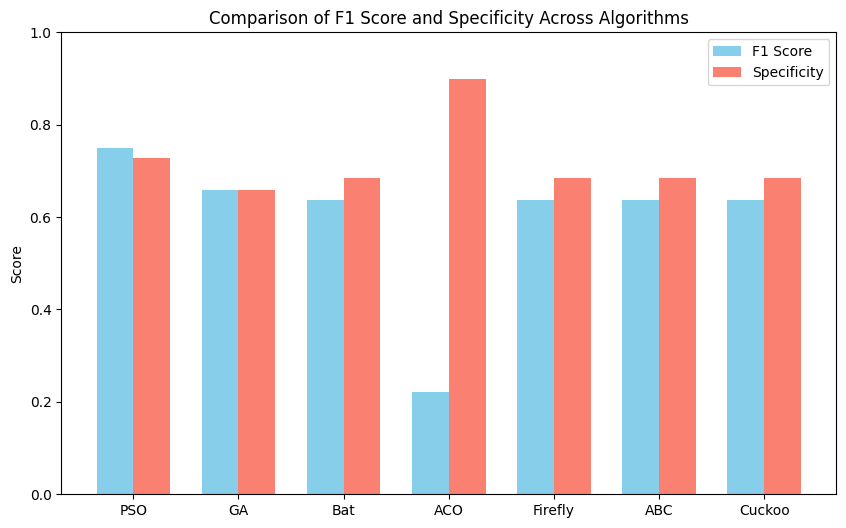

In [57]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(algorithms))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_scores, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, specificity, width, label='Specificity', color='salmon')

plt.xticks(x, algorithms)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('Comparison of F1 Score and Specificity Across Algorithms')
plt.legend()
plt.show()


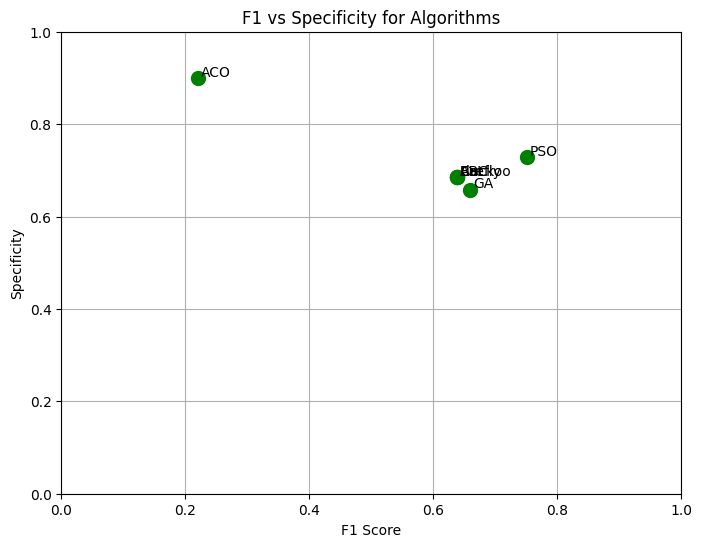

In [58]:
plt.figure(figsize=(8,6))
plt.scatter(f1_scores, specificity, color='green', s=100)

for i, alg in enumerate(algorithms):
    plt.text(f1_scores[i]+0.005, specificity[i]+0.005, alg)

plt.xlabel('F1 Score')
plt.ylabel('Specificity')
plt.title('F1 vs Specificity for Algorithms')
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.show()
